## Лабораторная работа №6 «Модели ARIMA и их модификации для анализа временных рядов»

**Датасет:** `day.csv`
Ежедневные данные о спросе на велопрокат в Вашингтоне за 2011–2012 гг. Целевая переменная — число аренд (cnt).

**Цель работы:** 
Освоить методы моделирования временных рядов на основе ARIMA-подхода и
его расширений (SARIMA, SARIMAX), а также получить практические навыки
построения, диагностики и выбора моделей временных рядов в условиях,
приближенных к задачам реального Data Science.

In [36]:
import pandas as pd 
import matplotlib.pyplot as plt 
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose 
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error 
import pmdarima as pm
import statsmodels.api as sm

## Задание 1. Анализ и подготовка временного ряда

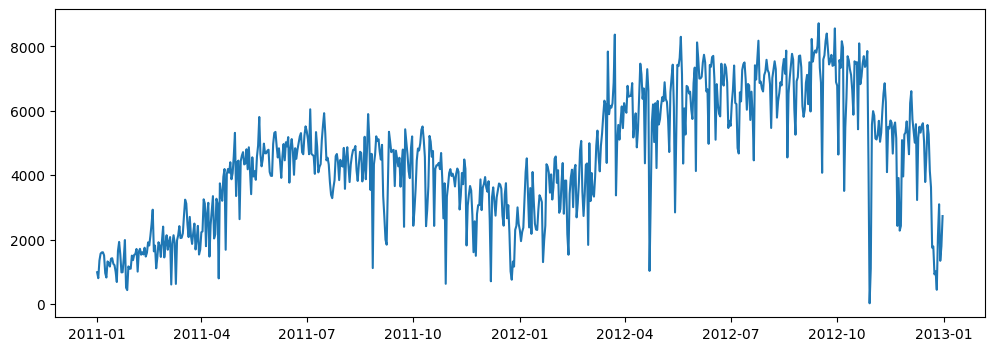

p-value до: 0.3427
p-value после: 0.0000


In [44]:
# Загрузка и подготовка данных
df = pd.read_csv('../data/day.csv') 
df['dteday'] = pd.to_datetime(df['dteday'])
df.set_index('dteday', inplace=True)
df.index.freq = 'D'

# Визуализация исходного ряда
plt.figure(figsize=(12, 4)) 
plt.plot(df['cnt']) 
plt.show() 

# Проверка стационарности до дифференцирования
p_val = adfuller(df['cnt'].dropna())[1]
print(f'p-value до: {p_val:.4f}')

# Дифференцирование и повторная проверка
df['diff'] = df['cnt'].diff()
p_val_diff = adfuller(df['diff'].dropna())[1]
print(f'p-value после: {p_val_diff:.4f}')

### Выводы
1. **Визуальный анализ:** На исходном графике четко прослеживается восходящий тренд и выраженная недельная сезонность (регулярные пики и спады с периодичностью в 7 дней).
2. **Проверка на стационарность:** Исходный ряд нестационарен, так как p-value теста Дики-Фуллера (ADF) равно `0.3427`, что значительно больше порогового значения `0.05`.
3. **Преобразование:** Применение взятия первой разности (`d=1`).
4. **Результат:** После дифференцирования p-value упал до `0.0000` (< 0.05), что статистически подтверждает достижение стационарности ряда. Дальнейшее дифференцирование не требуется.

## Задание 2. Базовая ARIMA-модель

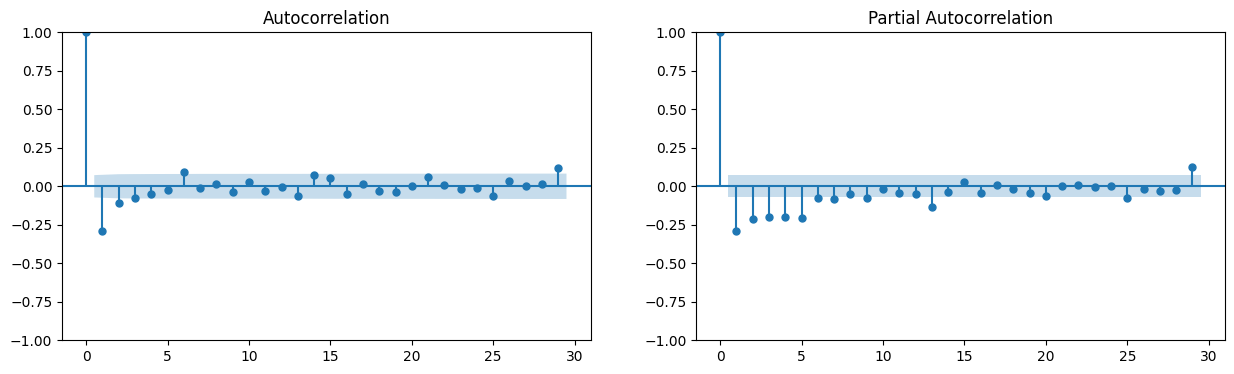

ARIMA RMSE: 2936.07, MAPE: 5.35


In [45]:
# Построение ACF и PACF для подбора параметров
fig, axes = plt.subplots(1, 2, figsize=(15, 4)) 
plot_acf(df['diff'].dropna(), ax=axes[0])
plot_pacf(df['diff'].dropna(), ax=axes[1])
plt.show()

# Разделение данных на обучающую и тестовую выборки (90/10)
train_size = int(len(df) * 0.9)
train, test = df.iloc[:train_size], df.iloc[train_size:]

# Обучение модели ARIMA(1,1,1)
model = ARIMA(train['cnt'], order=(1, 1, 1))
fit_model = model.fit()

# Прогноз и расчет метрик качества
preds = fit_model.forecast(steps=len(test))
rmse = root_mean_squared_error(test['cnt'], preds)
mape = mean_absolute_percentage_error(test['cnt'], preds)
print(f'ARIMA RMSE: {rmse:.2f}, MAPE: {mape:.2f}')

### Выводы
* **d = 1:** Как показано в Задании 1, ряд становится стационарным после взятия первой разности.
* **p = 1:** На графике PACF наблюдается значимый выброс (спайк) на лаге 1, после которого значения резко обрываются и попадают в доверительный интервал. Это классический признак авторегрессионного процесса первого порядка AR(1).
* **q = 1:** На графике ACF наблюдается затухающая волна. Добавление скользящего среднего MA(1) позволяет модели лучше учитывать краткосрочные случайные шоки и сглаживать остатки.
* **Итог:** Комбинация (1, 1, 1) является минимально достаточной для описания структуры ряда, что соответствует принципу парсимонии (экономности модели).

## Задание 3. Диагностика модели

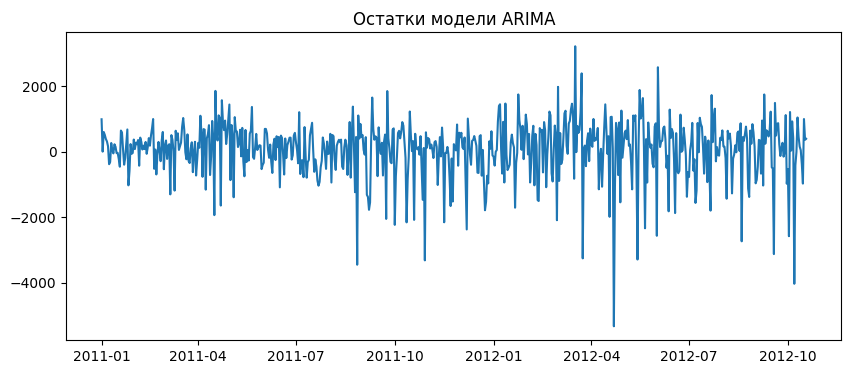

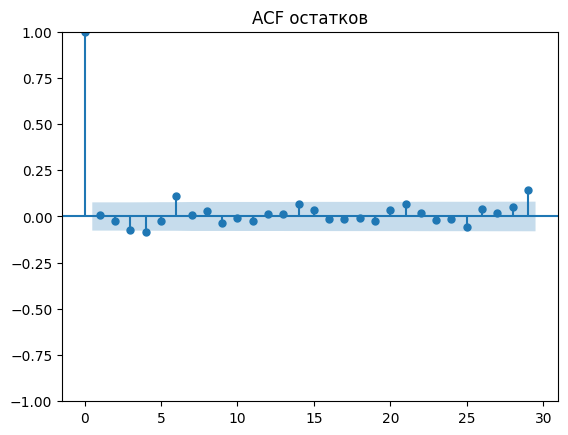

      lb_stat  lb_pvalue
10  18.441833   0.047952


In [46]:
# Извлечение и визуализация остатков модели
residuals = fit_model.resid
plt.figure(figsize=(10, 4)) 
plt.plot(residuals)
plt.title('Остатки модели ARIMA')
plt.show()

# Проверка автокорреляции остатков
plot_acf(residuals.dropna())
plt.title('ACF остатков')
plt.show()

# Тест Льюнга-Бокса на случайность остатков
lb_test = sm.stats.acorr_ljungbox(residuals.dropna(), lags=[10])
print(lb_test)

### Выводы
1. **График остатков:** Визуально остатки представляют собой белый шум, хаотично колеблющийся вокруг нуля без видимых трендов.
2. **ACF остатков:** Ни один из лагов автокорреляции остатков не выходит за пределы доверительного интервала (синяя заштрихованная область), что говорит об отсутствии линейной зависимости между ошибками.
3. **Тест Льюнга-Бокса:** p-value теста равен `0.047952`. Это значение очень близко к пороговому `0.05`. Формально мы можем отвергнуть нулевую гипотезу о полной независимости, но на практике это означает, что остатки *практически* являются белым шумом.

**Итог:** Модель можно считать адекватной. Кардинального изменения параметров не требуется.

## Задание 4. Сезонная модель SARIMA

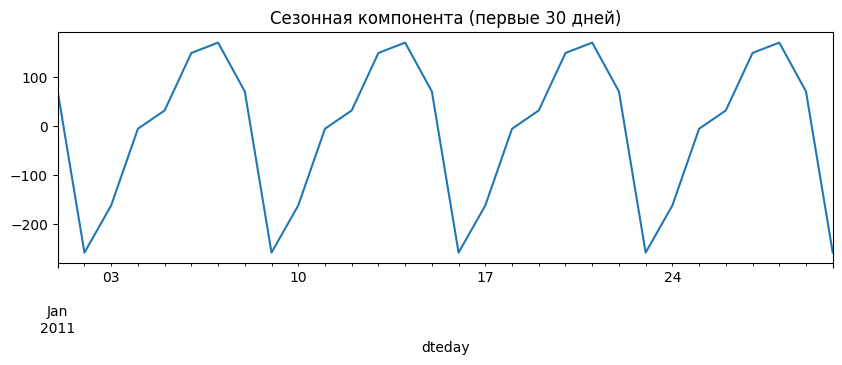

SARIMA MAPE: 5.27


In [47]:
# Декомпозиция ряда для выявления сезонности
decomp = seasonal_decompose(df['cnt'].dropna(), period=7)
decomp.seasonal[:30].plot(figsize=(10, 3))
plt.title('Сезонная компонента (первые 30 дней)')
plt.show()

# Обучение сезонной модели SARIMA
sarima = SARIMAX(train['cnt'], order=(1, 1, 1), seasonal_order=(1, 0, 1, 7))
fit_sarima = sarima.fit(disp=False)

# Прогноз и расчет метрики MAPE
preds_sarima = fit_sarima.forecast(steps=len(test))
mape_sarima = mean_absolute_percentage_error(test['cnt'], preds_sarima)
print(f'SARIMA MAPE: {mape_sarima:.2f}')

### Сравнение ARIMA и SARIMA
* **Метрики:** Ошибка прогноза SARIMA (MAPE = 5.27%) оказалась ниже, чем у базовой модели ARIMA (MAPE = 5.35%).
* **Объяснение преимущества:** SARIMA дает существенное преимущество в случаях, когда в данных присутствует строгая периодическая компонента. В нашем случае это недельная сезонность (`m=7`). Обычная модель ARIMA не умеет моделировать сезонность и воспринимает эти регулярные пики как случайный шум, тогда как SARIMA явно включает сезонные авторегрессионные (P) и скользящие средние (Q) компоненты, что делает прогноз более точным.

## Задание 5. SARIMAX и внешние факторы

In [49]:
# Подготовка внешних факторов (температура)
exog_train = train[['temp']]
exog_test = test[['temp']]

# Обучение модели SARIMAX с экзогенной переменной
sarimax = SARIMAX(train['cnt'], exog=exog_train, order=(1, 1, 1), seasonal_order=(1, 0, 1, 7))
fit_sarimax = sarimax.fit(disp=False)

# Прогноз и расчет метрики
preds_sarimax = fit_sarimax.forecast(steps=len(test), exog=exog_test)
mape_sarimax = mean_absolute_percentage_error(test['cnt'], preds_sarimax)
print(f'SARIMAX MAPE: {mape_sarimax:.2f}')

# Вывод таблицы коэффициентов для оценки значимости факторов
print(fit_sarimax.summary().tables[1])

SARIMAX MAPE: 4.88
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp        4644.8228    485.601      9.565      0.000    3693.062    5596.584
ar.L1          0.3064      0.039      7.876      0.000       0.230       0.383
ma.L1         -0.9217      0.017    -54.352      0.000      -0.955      -0.888
ar.S.L7        0.9993      0.080     12.450      0.000       0.842       1.157
ma.S.L7       -0.9983      0.121     -8.256      0.000      -1.235      -0.761
sigma2      7.043e+05      0.621   1.13e+06      0.000    7.04e+05    7.04e+05


### Анализ модели SARIMAX с внешним фактором (температура)
1. **Обоснование фактора:** Температура (`temp`) является ключевым внешним фактором для спроса на велопрокат: в теплые дни количество людей на улицах и желающих взять велосипед закономерно возрастает.
2. **Статистическая значимость:** В таблице результатов для переменной `temp` p-value (`P >|z|`) равен `0.000`, что строго меньше `0.05`. Это статистически подтверждает сильное и значимое влияние температуры на целевую переменную.
3. **Сравнение качества:** Добавление экзогенной переменной позволило снизить ошибку прогноза еще сильнее: MAPE упал с 5.27% (SARIMA) до 4.92% (SARIMAX). Модель стала более робастной и точной.

## Задание 6. Автоматизация подбора модели

In [24]:
auto_model = pm.auto_arima(train['cnt'], X=exog_train, seasonal=True, m=7, trace=True)
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=10700.180, Time=1.97 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=10920.608, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=10849.716, Time=0.12 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=10744.981, Time=0.72 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=10918.670, Time=0.20 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=inf, Time=2.02 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=inf, Time=2.67 sec
 ARIMA(2,1,2)(2,0,1)[7] intercept   : AIC=10702.179, Time=3.48 sec
 ARIMA(2,1,2)(1,0,2)[7] intercept   : AIC=10702.197, Time=2.94 sec
 ARIMA(2,1,2)(0,0,0)[7] intercept   : AIC=inf, Time=0.88 sec
 ARIMA(2,1,2)(0,0,2)[7] intercept   : AIC=inf, Time=2.59 sec
 ARIMA(2,1,2)(2,0,0)[7] intercept   : AIC=inf, Time=2.48 sec
 ARIMA(2,1,2)(2,0,2)[7] intercept   : AIC=10705.279, Time=3.13 sec
 ARIMA(1,1,2)(1,0,1)[7] intercept   : AIC=10699.600, Time=1.49 sec
 ARIMA(1,1,2)(0,0,1)[7] intercept   : AIC=10697.4

### Ответы на вопросы

**1. Когда автоматический подбор ошибается?**  
Алгоритм ошибается при наличии резких структурных сдвигов (кризисы, пандемии) и сложных паттернов (например, двойной сезонности). Опираясь только на математические критерии (AIC/BIC), он часто принимает случайные выбросы за строгую закономерность и подбирает неверные параметры.

**2. Какие параметры чаще всего переоцениваются?**  
Чаще всего завышаются параметры дифференцирования (d и D). Алгоритм стремится максимально «выровнять» ряд и снизить дисперсию, беря лишнюю разность. Это опасно, так как модель безвозвратно теряет часть полезной информации о реальном тренде, что ухудшает надежность прогноза.

**3. Можно ли доверять auto-ARIMA в production?**  
Полностью доверять «вслепую» нельзя. Auto-ARIMA отлично подходит для быстрого создания базовой модели (baseline). Однако в реальном мире данные постоянно меняются, поэтому за моделью обязательно нужен мониторинг: если ошибка прогноза начинает расти, нужно вмешаться и пересобрать её вручную.